In [1]:
# import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.power import FTestAnovaPower
from statsmodels.stats.power import TTestPower
from statsmodels.stats.multicomp import pairwise_tukeyhsd


## Create Synthetic Dataset

In [2]:
# set the number of rows
n = 80

# generate the data set

# create the categorical variables
# create the constant of 1 virus
virus = ['Influenza_B'] * n

# create the surfaces in the data set by assigning each equaly
surface = ["Stainless_Steel"] * 20 + ["Plastic"] * 20 + ["Granite"] * 20 + ["Glass"] * 20

# create the options for disinfectant
# need to select the two things equaly within each value of surface
disinfectant = []
for i in range(4):
    disinfectant.extend(["Control"] * 10 + ["Disinfectant"] * 10)

# create the application method
application = []
for i in range(8):
    application.extend(["Wipes"] * 5 + ["Spray"] * 5)

# create dataframe containing the categorical variables
df = pd.DataFrame({
    "Virus": virus,
    "Surface": surface,
    "Disinfectant": disinfectant,
    "Application" : application
})

# create continuous variables and add them to the dataframe
# use random seed to ensure replicability
np.random.seed(42)

# create the random values for temperature
df["Temperature_Celsius"] = np.random.uniform(17, 27, 80)
df["Temperature_Celsius"] = df["Temperature_Celsius"].round(2) # add to data frame and round

# function to create the random values for porosity based on surface
def get_porosity(surface):
    if surface == "Stainless_Steel":
        return np.random.uniform(0,0.2) #range determined from avg porosity of stainless steel
    elif surface == "Plastic":
        return 0
    elif surface == "Granite":
        return np.random.uniform(0.05,1.5) # range determined from avg. porosity of granite
    else:
        return 0

df['Porosity'] = df['Surface'].apply(get_porosity) #run function using surface as input
df['Porosity'] = df['Porosity'].round(2) #add to dataframe and round


# create random values for time based on all input variables

# set seed for reproducibility
np.random.seed(42)

# empty list
time_list = []


# loop to create all time values based on inputs
for i, row in df.iterrows():
    if row["Disinfectant"] == "Control":
        # control: 24–48 h in minutes
        if row["Surface"] == "Stainless_Steel":
            time = np.random.randint(1900, 2100)
        elif row["Surface"] == "Plastic":
            time = np.random.randint(1800, 2000)
        elif row["Surface"] == "Granite":
            time = np.random.randint(2000, 2200)
        else:  # glass
            time = np.random.randint(1850, 2050)

    else:
        # disinfectant: spray slightly faster than wipes
        if row["Surface"] == "Stainless_Steel":
            if row["Application"] == "Wipes":
                time = np.random.randint(8, 14)
            elif row["Application"] == "Spray":
                time = np.random.randint(2, 5)

        elif row["Surface"] == "Plastic":
            if row["Application"] == "Wipes":
                time = np.random.randint(8, 13)
            elif row["Application"] == "Spray":
                time = np.random.randint(2, 6)

        elif row["Surface"] == "Granite":
            if row["Application"] == "Wipes":
                time = np.random.randint(10, 15)
            elif row["Application"] == "Spray":
                time = np.random.randint(3, 7)

        else:  # glass
            if row["Application"] == "Wipes":
                time = np.random.randint(8, 12)
            elif row["Application"] == "Spray":
                time = np.random.randint(2, 5)
                
    #add explicit application significance
    if row["Application"] == "Spray" and row["Disinfectant"] == "Disinfectant":
        time = max(1, time - 4)

    time_list.append(time)
# assign time values to the dataframe
df["Time"] = time_list

# add new columns for crossover/washout RCT

# create empty lists
application_2_list = []
time_2_list = []

# assign new applications that are opposite of original application
for i, row in df.iterrows():

    # flip application
    if row["Application"] == "Wipes":
        app2 = "Spray"
    else:
        app2 = "Wipes"

    application_2_list.append(app2)

    # create Time_2
    time2 = row["Time"]

    if app2 == "Spray":
        time2 = time2 + 2.0 #ensure slight effect that spray to wipes is better than wipes to spray

    time_2_list.append(time2)

# add new columns to dataframe
df["Application_2"] = application_2_list
df["Time_2"] = time_2_list

# add new columns for withdrawal RCT

# subset data to only use the 'Disinfectant' rows
df_w = df[df["Disinfectant"] == "Disinfectant"].copy()

# assign withdrawal status (50/50 split)
np.random.seed(42)
mask = np.random.rand(len(df_w)) < 0.5
df_w['Withdrawal_Status'] = np.where(mask, 'Continued', 'Withdrawn')

# generate viral load data (T1 = baseline, T2 = after withdrawal period)
df_w['Viral_Load_T1'] = np.random.uniform(5, 15, len(df_w))

def calculate_rebound(row):
    if row['Withdrawal_Status'] == 'Withdrawn':
        # High rebound because disinfectant was stopped
        return row['Viral_Load_T1'] + np.random.uniform(100, 300)
    else:
        # Low rebound because disinfectant continued
        return row['Viral_Load_T1'] + np.random.uniform(0, 20)

df_w['Viral_Load_T2'] = df_w.apply(calculate_rebound, axis=1)

# merge subset data back to original df
# merging creates NaN for original Control group rows
df = df.merge(
    df_w[['Withdrawal_Status', 'Viral_Load_T1', 'Viral_Load_T2']],
    left_index=True,
    right_index=True,
    how='left'
)


# create matched pairs for matched pairs RCT

# shuffle data to avoid pairing bias
np.random.seed(42)
df = df.sample(frac=1).reset_index(drop=True)

# create empty column
df["Pair_ID"] = np.nan

pair_id = 1 #set starting pair id

# group by the controlled variables
for (surface, disinfectant), group in df.groupby(["Surface", "Disinfectant"]):
    wipe_rows = group[group["Application"] == "Wipes"].index.tolist()
    spray_rows = group[group["Application"] == "Spray"].index.tolist()

    # ensure equal matching
    n_pairs = min(len(wipe_rows), len(spray_rows))

    for i in range(n_pairs):
        df.loc[wipe_rows[i], "Pair_ID"] = pair_id
        df.loc[spray_rows[i], "Pair_ID"] = pair_id
        pair_id += 1

# convert to integer
df["Pair_ID"] = df["Pair_ID"].astype("Int64")


# add temp block
df["Temp_Block"] = pd.qcut(df["Temperature_Celsius"], q=3, labels=['Low', 'Mid', 'High'])

df.head(25)

,Virus,Surface,Disinfectant,Application,Temperature_Celsius,Porosity,Time,Application_2,Time_2,Withdrawal_Status,Viral_Load_T1,Viral_Load_T2,Pair_ID,Temp_Block
0,Influenza_B,Plastic,Disinfectant,Wipes,23.08,0.00,10,Spray,12.0,Continued,14.695846,17.087731,26,Mid
1,Influenza_B,Stainless_Steel,Control,Wipes,20.75,0.17,2002,Spray,2004.0,NaN,NaN,NaN,31,Mid
2,Influenza_B,Plastic,Control,Wipes,19.92,0.00,1991,Spray,1993.0,NaN,NaN,NaN,21,Mid
3,Influenza_B,Plastic,Disinfectant,Wipes,18.71,0.00,10,Spray,12.0,Withdrawn,12.751328,255.400286,27,Low
4,Influenza_B,Stainless_Steel,Disinfectant,Spray,21.32,0.01,1,Wipes,1.0,Withdrawn,10.467103,287.909651,36,Mid
5,Influenza_B,Plastic,Control,Spray,22.92,0.00,1888,Wipes,1888.0,NaN,NaN,NaN,21,Mid
6,Influenza_B,Stainless_Steel,Disinfectant,Wipes,17.21,0.02,10,Spray,12.0,Continued,6.220382,23.482451,36,Low
7,Influenza_B,Glass,Disinfectant,Wipes,24.72,0.00,11,Spray,13.0,Withdrawn,12.722448,170.672738,6,High
8,Influenza_B,Stainless_Steel,Control,Wipes,18.56,0.06,2006,Spray,2008.0,NaN,NaN,NaN,32,Low
9,Influenza_B,Stainless_Steel,Disinfectant,Wipes,25.32,0.15,10,Spray,12.0,Withdrawn,5.343885,171.523490,37,High


In [3]:
df.describe()

,Temperature_Celsius,Porosity,Time,Time_2,Viral_Load_T1,Viral_Load_T2,Pair_ID
count,80.000000,80.000000,80.000000,80.000000,40.000000,40.000000,80.0
mean,21.658875,0.222375,995.875000,996.875000,9.755146,108.291190,20.5
std,3.056866,0.398755,998.382748,998.391293,3.188626,107.530005,11.616226
min,17.060000,0.000000,1.000000,1.000000,5.055221,5.960655,1.0
25%,18.845000,0.000000,7.000000,8.500000,6.932008,17.868600,10.75
50%,21.360000,0.005000,916.500000,918.000000,9.419271,26.179509,20.5
75%,24.417500,0.162500,1994.500000,1996.000000,12.729668,209.621496,30.25
max,26.870000,1.400000,2189.000000,2191.000000,14.868869,287.909651,40.0


## Exploratory Data Analysis

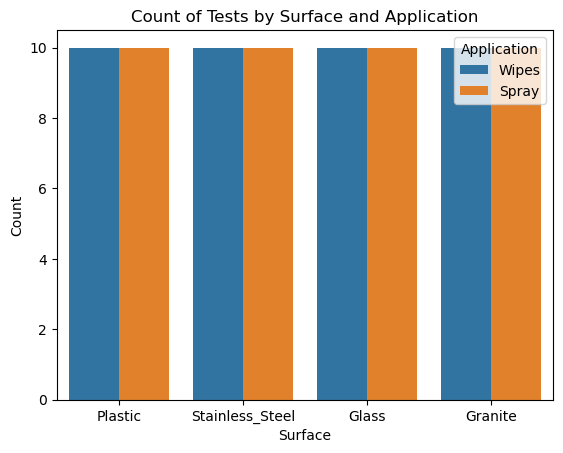

In [4]:
# create a bar chart to look at the count of application instances by surface
# shows that there is an equal number of wipe and spary applications for each surface
sns.countplot(x="Surface", hue="Application", data = df)

plt.title('Count of Tests by Surface and Application')
plt.ylabel('Count')
plt.xlabel('Surface')
plt.show()

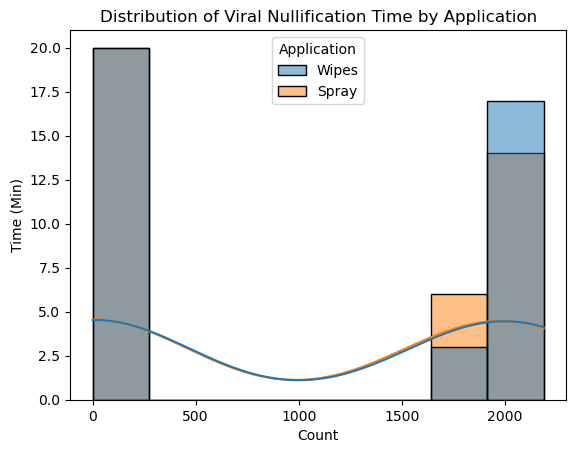

In [5]:
# histogram for time
# looks at the time distribution to nullify the virus by application type
# shows that there is little difference in application for the disinfectant group
# shows that there is slightly higher nullificaiton time for wipes than spray for the control group

sns.histplot(x="Time", kde=True, hue="Application" ,data=df)

plt.title('Distribution of Viral Nullification Time by Application')
plt.ylabel('Time (Min)')
plt.xlabel('Count')
plt.show()

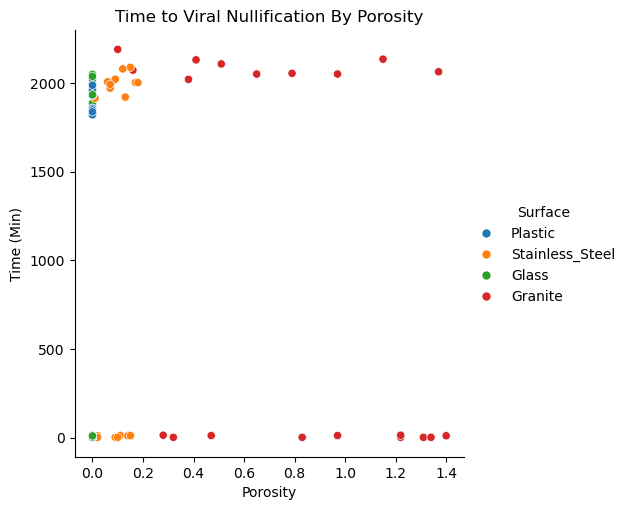

In [6]:
# Scatter plot to visualize relationship between porosiy, surface, application and time
# shows that there is some range in porosity for stainless steel and granite
# shows that there is no visual relationship between prorosity or surface and time to viral nullification
sns.relplot(data=df, x='Porosity', y='Time', hue='Surface')

plt.title('Time to Viral Nullification By Porosity')
plt.ylabel('Time (Min)')
plt.xlabel('Porosity')
plt.show()

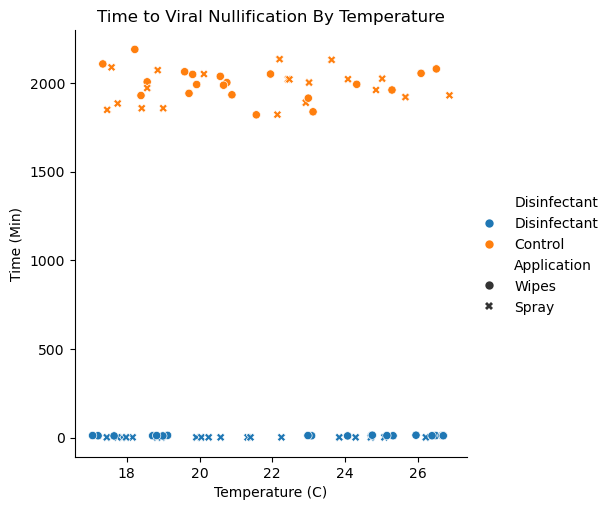

In [7]:
#Time vs Tempature with Surface 
# Shows that there is a large time differential to viral nullification between disinfectant and control
# There is no clear pattern of time to nullification based on temperature or application
sns.relplot(data=df, x='Temperature_Celsius', y='Time', hue="Disinfectant", style='Application')


plt.title('Time to Viral Nullification By Temperature')
plt.ylabel('Time (Min)')
plt.xlabel('Temperature (C)')
plt.show()




In [8]:
# Create long dataframe for visualization of the viral load across time

# select the relevant columns
df_plot = df[['Viral_Load_T1', 'Viral_Load_T2', 'Withdrawal_Status']].copy()

# drop rows with nulls
df_plot = df_plot.dropna(subset=['Viral_Load_T1', 'Viral_Load_T2'])

# melt T1 and T2 into one column
df_long = pd.melt(
    df_plot,
    id_vars=['Withdrawal_Status'], 
    value_vars=['Viral_Load_T1', 'Viral_Load_T2'],
    var_name='Time_Point',        
    value_name='Viral_Load'            
)

# rename for clarity
df_long['Time_Point'] = df_long['Time_Point'].map({'Viral_Load_T1': 'T1', 'Viral_Load_T2': 'T2'})



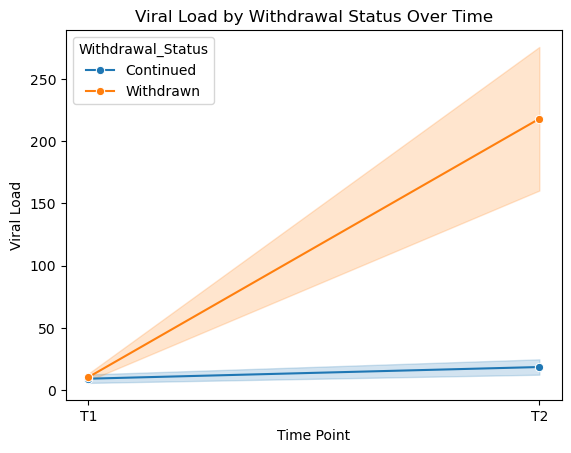

In [9]:
#Viral Load vs Withdrawl Status
# Shows that there is a large difference in viral load between those that continued to receive disinfectant
# and those that later received control

sns.lineplot(
    data=df_long,
    x='Time_Point',
    y='Viral_Load',
    hue='Withdrawal_Status',  
    marker='o',
    errorbar="sd"
)

plt.title('Viral Load by Withdrawal Status Over Time')
plt.ylabel('Viral Load')
plt.xlabel('Time Point')
plt.show()

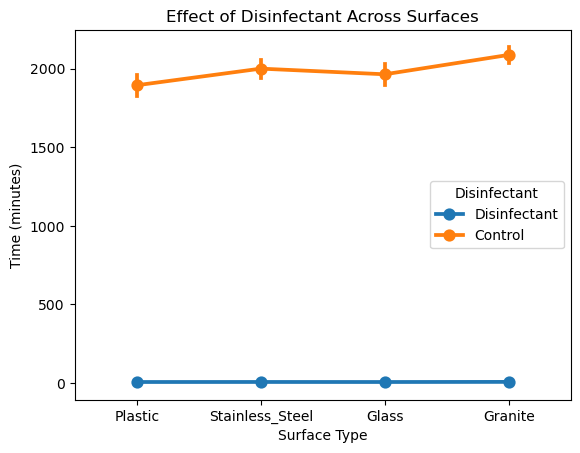

In [10]:

#Disinfectant vs Surface 
# Shows that there are slight differences between the time to nullificaiton for surface when recieving the control
# This pattern is not visible for the surfaces that received disinfectant

sns.pointplot(
    data=df,
    x="Surface",
    y="Time",
    hue="Disinfectant",
    errorbar="sd"
)

plt.title("Effect of Disinfectant Across Surfaces")
plt.ylabel("Time (minutes)")
plt.xlabel("Surface Type")

plt.show()

## Parallel Randomized Control Trial

In [11]:
# Subset data for Parallel RCT
df_parallel = df[[
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Time",
    "Temperature_Celsius",
    "Temp_Block"
]].copy()

df_parallel.head()

,Virus,Surface,Disinfectant,Application,Time,Temperature_Celsius,Temp_Block
0,Influenza_B,Plastic,Disinfectant,Wipes,10,23.08,Mid
1,Influenza_B,Stainless_Steel,Control,Wipes,2002,20.75,Mid
2,Influenza_B,Plastic,Control,Wipes,1991,19.92,Mid
3,Influenza_B,Plastic,Disinfectant,Wipes,10,18.71,Low
4,Influenza_B,Stainless_Steel,Disinfectant,Spray,1,21.32,Mid


### Hypothesis
Main Effect Disinfectant:  
H0: There is no difference in mean time to nullify the virus between disinfectant and control treatments, after controlling for temperature.  
H1: There is a difference in mean time to nullify the virus between disinfectant and control treatments, after controlling for temperature.
    
Main Effect Application:  
H0: There is no difference in mean time to nullify the virus between spray and wipe application, after controlling for temperature.  
H1: There is a difference in mean time to nullify the virus between spray and wipe application, after controlling for temperature.  


### ANOVA
##### Testing the interaction between Disinfectant and Application Method

In [12]:
#ANOVA 1: Testing the interaction between Disinfectant and Application Method
# This checks if 'Spray' vs 'Wipes' actually changes the 'Time' outcome  differently depending on whether it's a Control or Disinfectant.

# standard blocked ANOVA
model_anova1 = smf.ols(
    "Time ~ C(Disinfectant) + C(Application) + C(Temp_Block)",
    data=df_parallel
).fit()

anova_results_1 = anova_lm(model_anova1, typ=2)

print("\nANOVA 1: Disinfectant + Application")
print(anova_results_1)


ANOVA 1: Disinfectant + Application
                       sum_sq    df             F        PR(>F)
C(Disinfectant)  7.611930e+07   1.0  17647.256613  9.103174e-91
C(Application)   4.628044e+03   1.0      1.072951  3.036081e-01
C(Temp_Block)    2.327138e+02   2.0      0.026976  9.733942e-01
Residual         3.235034e+05  75.0           NaN           NaN


### Pairwise Tukey Test

In [13]:
# Tukey HSD for Application
tukey_app = pairwise_tukeyhsd(
    endog=df["Time"], #continuous outcome
    groups=df["Disinfectant"], #grouping variable
    alpha=0.05
)

print(tukey_app)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
 group1    group2    meandiff p-adj   lower      upper    reject
----------------------------------------------------------------
Control Disinfectant  -1980.1   0.0 -2009.0012 -1951.1988   True
----------------------------------------------------------------


### Power Analysis

Power analysis was conducted without blocking, making it a conservative estimate. Inclusion of temperature blocks is expected to increase statistical power.

In [14]:
# Model blocking factor only
block_model = smf.ols("Time ~ C(Temp_Block)", data=df_parallel).fit()

# Residuals = Time adjusted for temperature
df_parallel["Time_adj"] = block_model.resid

# Groups by application (using adjusted values)
groups = [
    df_parallel[df_parallel["Application"] == "Wipes"]["Time_adj"].values,
    df_parallel[df_parallel["Application"] == "Spray"]["Time_adj"].values,
]

# Grand mean
data = np.concatenate(groups)
grand_mean = np.mean(data)

# Sum of squares
ss_between = sum(len(g) * (np.mean(g) - grand_mean) ** 2 for g in groups)
ss_within = sum(np.sum((g - np.mean(g)) ** 2) for g in groups)

# Cohen's f (adjusted for block)
effect_size = np.sqrt(ss_between / ss_within)
print(f"Cohen's f (Application effect, blocked): {effect_size:.2f}")

power_analysis = FTestAnovaPower()

sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    k_groups=2
)

print(f"Required sample size per group (blocked design): {sample_size:.0f}")

Cohen's f (Application effect, blocked): 0.03
Required sample size per group (blocked design): 8356


## Factorial Randomized Control Trial

In [15]:
# subset dataset for factorial RCT
df_factorial = df[[
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Time",
    "Temperature_Celsius",
    "Temp_Block"
]].copy()

#df[df["Disinfectant"] == "Disinfectant"].copy()


### Hypothesis
Main Effect Disinfectant:  
H0: There is no difference in mean time to nullify the virus between disinfectant and control treatments, after controlling for temperature.  
H1: There is a difference in mean time to nullify the virus between disinfectant and control treatments, after controlling for temperature.
    
Main Effect Application Method:  
H0: There is no difference in mean time to nullify the virus between spray and wipe application, after controlling for temperature.  
H1: There is a difference in mean time to nullify the virus between spray and wipe application, after controlling for temperature. 
   
Main Effect Surface:  
H0: There is no difference in mean time to nullify the virus between surfaces, after controlling for temperature.  
H1: There is a difference in mean time to nullify the virus between surfaces, after controlling for temperature.  
  
Interaction Effect Application x Surface:  
H0: There is no interaction between application method and surface, the effect of application method on time to nullify the virus is the same for all surfaces, after controlling for temperature.  
H1: There is an interaction between application method and surface, the effect of application method on time to nullify the virus depends on the surface type, after controlling for temperature.


### ANOVA
##### Testing the factorial interaction between Disinfectant Application Method and Surface

In [16]:
# two-way factorial ANOVA

# We use 'Time' as the dependent variable to see if disinfectant application effectiveness depends
# on the specific surface it's applied to.

model = smf.ols('Time ~ C(Disinfectant) + C(Application) + C(Surface) +C(Temp_Block) + C(Application):C(Surface)',
            data=df_factorial).fit()

anova_table = anova_lm(model, typ=2)
print("Two-way Factorial ANOVA Table:\n")
print(anova_table)

Two-way Factorial ANOVA Table:

                                 sum_sq    df             F        PR(>F)
C(Disinfectant)            7.597959e+07   1.0  23355.066812  4.661320e-89
C(Application)             4.868129e+03   1.0      1.496395  2.253882e-01
C(Surface)                 9.747181e+04   3.0      9.987158  1.502336e-05
C(Temp_Block)              1.349732e+02   2.0      0.020744  9.794754e-01
C(Application):C(Surface)  1.558151e+03   3.0      0.159651  9.231030e-01
Residual                   2.244734e+05  69.0           NaN           NaN


### Pairwise Tukey Test

In [17]:
# Post-hoc Tukey HSD
# look at the interaction between surfaces

# Run pairwise Tukey HSD
tukey_surface = pairwise_tukeyhsd(
    endog=df_factorial['Time'],
    groups=df_factorial['Surface'],
    alpha=0.05
)

print(tukey_surface)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
 group1      group2     meandiff p-adj    lower    upper   reject
-----------------------------------------------------------------
  Glass         Granite    62.05 0.9974 -782.9584 907.0584  False
  Glass         Plastic   -34.85 0.9995 -879.8584 810.1584  False
  Glass Stainless_Steel     18.1 0.9999 -826.9084 863.1084  False
Granite         Plastic    -96.9 0.9904 -941.9084 748.1084  False
Granite Stainless_Steel   -43.95 0.9991 -888.9584 801.0584  False
Plastic Stainless_Steel    52.95 0.9984 -792.0584 897.9584  False
-----------------------------------------------------------------


### Power Analysis

In [18]:
# conduct power analysis calculating effect size from data

# model with blocking factor only
block_model = smf.ols("Time ~ C(Temp_Block)", data=df_factorial).fit()
df_factorial["Time_adj"] = block_model.resid

# Create groupings by surface
groups = [
    group["Time_adj"].dropna()
    for _, group in df_factorial.groupby(["Surface", "Application"])
]

# Calculate mean of combined data
dataFact = np.concatenate(groups)
dataFact_mean = np.mean(dataFact)

# Calculate sum of squares between groups
ss_between = sum(
    len(group) * (np.mean(group) - dataFact_mean) ** 2
    for group in groups
)

# Calculate sum of squares within groups
ss_within = sum(
    np.sum((group - np.mean(group)) ** 2)
    for group in groups
)

# Calculate effect size using Cohen's f
effect_size = np.sqrt(ss_between / ss_within)

# Display effect size result
print(f'Effect size: {effect_size:.2f}')

# Conduct power analysis
power_analysis = FTestAnovaPower()
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    k_groups=len(groups)
)

# Display power analysis result
print(f'The sample size required per group is: {sample_size:.0f}')

Effect size: 0.06
The sample size required per group is: 3669


## Crossover Randomized Control Trial

### Subset the Data

In [19]:
# subset data to create new data set crossover RCT
df_crossover = df[[
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Time",
    "Application_2",
    "Time_2",
    "Temperature_Celsius",
    "Temp_Block"
]].copy()

df_crossover.head(10)

,Virus,Surface,Disinfectant,Application,Time,Application_2,Time_2,Temperature_Celsius,Temp_Block
0,Influenza_B,Plastic,Disinfectant,Wipes,10,Spray,12.0,23.08,Mid
1,Influenza_B,Stainless_Steel,Control,Wipes,2002,Spray,2004.0,20.75,Mid
2,Influenza_B,Plastic,Control,Wipes,1991,Spray,1993.0,19.92,Mid
3,Influenza_B,Plastic,Disinfectant,Wipes,10,Spray,12.0,18.71,Low
4,Influenza_B,Stainless_Steel,Disinfectant,Spray,1,Wipes,1.0,21.32,Mid
5,Influenza_B,Plastic,Control,Spray,1888,Wipes,1888.0,22.92,Mid
6,Influenza_B,Stainless_Steel,Disinfectant,Wipes,10,Spray,12.0,17.21,Low
7,Influenza_B,Glass,Disinfectant,Wipes,11,Spray,13.0,24.72,High
8,Influenza_B,Stainless_Steel,Control,Wipes,2006,Spray,2008.0,18.56,Low
9,Influenza_B,Stainless_Steel,Disinfectant,Wipes,10,Spray,12.0,25.32,High


In [20]:
# filter to only disinfectant rows — crossover of application
# method (wipes vs spray) is only meaningful when disinfectant is applied
df_crossover = df_crossover[df_crossover["Disinfectant"] == "Disinfectant"].copy()

# create a Sequence column to track the order of treatments
# e.g. "Wipes_then_Spray" or "Spray_then_Wipes"
df_crossover["Sequence"] = (
    df_crossover["Application"] + "_then_" + df_crossover["Application_2"]
)

# reshape data to long format (one row per subject per period)
# this is needed because in a crossover design, each subject
# receives BOTH treatments across two time periods

# Period 1: original application and time
df_period1 = df_crossover[["Surface", "Application", "Time", "Sequence"]].copy()
df_period1.rename(columns={"Application": "Treatment", "Time": "Outcome"}, inplace=True)
df_period1["Period"] = "Period_1"

# Period 2: crossover application and time
df_period2 = df_crossover[["Surface", "Application_2", "Time_2", "Sequence"]].copy()
df_period2.rename(columns={"Application_2": "Treatment", "Time_2": "Outcome"}, inplace=True)
df_period2["Period"] = "Period_2"

# combine into one long dataframe
df_crossover_long = pd.concat([df_period1, df_period2], ignore_index=True)

print("Crossover long format shape:", df_crossover_long.shape)
df_crossover_long.head(10)

Crossover long format shape: (80, 5)


,Surface,Treatment,Outcome,Sequence,Period
0,Plastic,Wipes,10.0,Wipes_then_Spray,Period_1
1,Plastic,Wipes,10.0,Wipes_then_Spray,Period_1
2,Stainless_Steel,Spray,1.0,Spray_then_Wipes,Period_1
3,Stainless_Steel,Wipes,10.0,Wipes_then_Spray,Period_1
4,Glass,Wipes,11.0,Wipes_then_Spray,Period_1
5,Stainless_Steel,Wipes,10.0,Wipes_then_Spray,Period_1
6,Plastic,Wipes,11.0,Wipes_then_Spray,Period_1
7,Plastic,Spray,1.0,Spray_then_Wipes,Period_1
8,Glass,Wipes,11.0,Wipes_then_Spray,Period_1
9,Granite,Spray,1.0,Spray_then_Wipes,Period_1


### Hypothesis
Main Effect Treatment:  
H0: The mean time to nullify the virus is the same for wipes and spray, regardless of the period, after controlling for temperature.  
H1: The mean time to nullify the virus differs between wipes and spray, after controlling for temperature.  
   
Main Effect of Period:  
H0: The mean time to nullify the virus is the same in Period 1 and Period 2, regardless of the treatment (wipe vs. spray), after controlling for temperature.  
H1: The mean time to nullify the virus differs between Period 1 and Period 2, after controlling for temperature.  
  
Interaction Effect Treatment  x Period:  
H0: The effect of treatment is consistent across periods, after controlling for temperature.  
H1: The effect of treatment differs depending on the period,after controlling for temperature.

### ANOVA
##### Testing the factorial interaction between Disinfectant Application Method and Surface

In [21]:
# two-way ANOVA for crossover design
# Factor 1: Treatment (Wipes vs Spray) — the actual method used
# Factor 2: Period (Period_1 vs Period_2) — checks for carryover effects
# Interaction: does the treatment effect change depending on the period?
model_crossover = smf.ols(
    "Outcome ~ C(Treatment) * C(Period)",
    data=df_crossover_long
).fit()

anova_crossover = anova_lm(model_crossover, typ=2)

print("Two-way ANOVA: Treatment * Period (Crossover RCT)\n")
print(anova_crossover)

Two-way ANOVA: Treatment * Period (Crossover RCT)

                         sum_sq    df            F        PR(>F)
C(Treatment)              20.00   1.0    30.957230  3.780123e-07
C(Period)                 20.00   1.0    30.957230  3.780123e-07
C(Treatment):C(Period)  2268.45   1.0  3511.246436  2.262688e-65
Residual                  49.10  76.0          NaN           NaN


### Pairwise Tukey Test

In [22]:
# create a combined group label for pairwise comparison
# this gives us 4 groups: Wipes_Period_1, Wipes_Period_2,
#                          Spray_Period_1, Spray_Period_2
df_crossover_long["Group"] = (
    df_crossover_long["Treatment"] + "_" + df_crossover_long["Period"]
)

# run pairwise Tukey HSD test
tukey_crossover = pairwise_tukeyhsd(
    endog=df_crossover_long["Outcome"],
    groups=df_crossover_long["Group"],
    alpha=0.05
)

print("Pairwise Tukey HSD Test (Crossover RCT)\n")
print(tukey_crossover)

Pairwise Tukey HSD Test (Crossover RCT)

         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj  lower    upper   reject
---------------------------------------------------------------------
Spray_Period_1 Spray_Period_2    11.65   0.0  10.9823  12.3177   True
Spray_Period_1 Wipes_Period_1     9.65   0.0   8.9823  10.3177   True
Spray_Period_1 Wipes_Period_2      0.0   1.0  -0.6677   0.6677  False
Spray_Period_2 Wipes_Period_1     -2.0   0.0  -2.6677  -1.3323   True
Spray_Period_2 Wipes_Period_2   -11.65   0.0 -12.3177 -10.9823   True
Wipes_Period_1 Wipes_Period_2    -9.65   0.0 -10.3177  -8.9823   True
---------------------------------------------------------------------


### Power Analysis

In [23]:
# create groups by treatment for effect size calculation
groups_crossover = [
    df_crossover_long[df_crossover_long["Treatment"] == "Wipes"]["Outcome"].dropna(),
    df_crossover_long[df_crossover_long["Treatment"] == "Spray"]["Outcome"].dropna(),
]

# calculate overall mean
data_crossover = np.concatenate(groups_crossover)
data_crossover_mean = np.mean(data_crossover)

# calculate sum of squares between groups
ss_between = sum(
    len(group) * (np.mean(group) - data_crossover_mean) ** 2
    for group in groups_crossover
)

# calculate sum of squares within groups
ss_within = sum(
    np.sum((group - np.mean(group)) ** 2)
    for group in groups_crossover
)

# calculate effect size using Cohen's f
effect_size_crossover = np.sqrt(ss_between / ss_within)
print(f"Effect size (Cohen's f): {effect_size_crossover:.2f}")

# conduct power analysis
power_analysis = FTestAnovaPower()
sample_size_crossover = power_analysis.solve_power(
    effect_size=effect_size_crossover,
    power=0.80,
    alpha=0.05,
    k_groups=2  # 2 treatment groups: Wipes vs Spray
)

print(f"Required sample size per group: {sample_size_crossover:.0f}")

Effect size (Cohen's f): 0.09
Required sample size per group: 919


## Withdrwal Randomized Control Trial

### Subset the Data

In [24]:
# subset data to create new data set for withdrawal

#create filter to remove control rows
mask = df["Disinfectant"] == "Disinfectant"

# create new dataframe with only the filtered rows
df_withdrawal = df.loc[mask, [
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Time",
    "Withdrawal_Status",
    "Viral_Load_T1",
    "Viral_Load_T2",
    "Temperature_Celsius",
    "Temp_Block"
]].copy()

df_withdrawal.head(10)


,Virus,Surface,Disinfectant,Application,Time,Withdrawal_Status,Viral_Load_T1,Viral_Load_T2,Temperature_Celsius,Temp_Block
0,Influenza_B,Plastic,Disinfectant,Wipes,10,Continued,14.695846,17.087731,23.08,Mid
3,Influenza_B,Plastic,Disinfectant,Wipes,10,Withdrawn,12.751328,255.400286,18.71,Low
4,Influenza_B,Stainless_Steel,Disinfectant,Spray,1,Withdrawn,10.467103,287.909651,21.32,Mid
6,Influenza_B,Stainless_Steel,Disinfectant,Wipes,10,Continued,6.220382,23.482451,17.21,Low
7,Influenza_B,Glass,Disinfectant,Wipes,11,Withdrawn,12.722448,170.672738,24.72,High
9,Influenza_B,Stainless_Steel,Disinfectant,Wipes,10,Withdrawn,5.343885,171.523490,25.32,High
11,Influenza_B,Plastic,Disinfectant,Wipes,11,Continued,13.948274,25.173817,26.49,High
13,Influenza_B,Plastic,Disinfectant,Spray,1,Continued,14.218742,24.094654,25.08,High
16,Influenza_B,Glass,Disinfectant,Wipes,11,Withdrawn,13.154614,274.778690,25.15,High
18,Influenza_B,Granite,Disinfectant,Spray,1,Withdrawn,10.426961,160.285407,26.22,High


### Hypothesis
Main Effect Withdrawal Status:  
H0: Viral rebound does not differ between withdrawal status groups treatment withdrawn vs maintained, after controlling for temperature.  
H1: Viral rebound differs between withdrawal status groups, after controlling for temperature.  
  
Main Effect Application Method:  
H0: Viral rebound does not differ between application methods, after controlling for temperature.  
H1: Viral rebound differs between application methods,after controlling for temperature. 
   
Main Effect Surface:  
H0: Viral rebound does not differ across surfaces, after controlling for temperature.  
H1: Viral rebound differs across surfaces, after controlling for temperature.  
  
Interaction Effect Application x Surface:  
H0: The effect of application method is consistent across all surfaces, after controlling for temperature.  
H1: The effect of application method depends on the surface type, after controlling for temperature.

In [25]:
# create rebound / change score as the outcome
# this measures how much viral load increased after the withdrawal period
df_withdrawal["Viral_Rebound"] = (
    df_withdrawal["Viral_Load_T2"] - df_withdrawal["Viral_Load_T1"]
)

print("Withdrawal subset shape:", df_withdrawal.shape)
print(df_withdrawal.head())

Withdrawal subset shape: (40, 11)
         Virus          Surface  Disinfectant Application  Time  \
0  Influenza_B          Plastic  Disinfectant       Wipes    10   
3  Influenza_B          Plastic  Disinfectant       Wipes    10   
4  Influenza_B  Stainless_Steel  Disinfectant       Spray     1   
6  Influenza_B  Stainless_Steel  Disinfectant       Wipes    10   
7  Influenza_B            Glass  Disinfectant       Wipes    11   

  Withdrawal_Status  Viral_Load_T1  Viral_Load_T2  Temperature_Celsius  \
0         Continued      14.695846      17.087731                23.08   
3         Withdrawn      12.751328     255.400286                18.71   
4         Withdrawn      10.467103     287.909651                21.32   
6         Continued       6.220382      23.482451                17.21   
7         Withdrawn      12.722448     170.672738                24.72   

  Temp_Block  Viral_Rebound  
0        Mid       2.391885  
3        Low     242.648957  
4        Mid     277.442549 

### ANOVA
##### Testing effect of Withdrawal Status, Application Method, and Surface Type on Viral Rebound.

In [26]:
model_withdrawal = smf.ols(
    "Viral_Rebound ~ C(Withdrawal_Status)+C(Application)+C(Surface)+C(Application):C(Surface)",
    data=df_withdrawal
).fit()

anova_withdrawal = anova_lm(model_withdrawal, typ=2)

print("Two-way ANOVA: Application * Surface (Withdrawal RCT)\n")
print(anova_withdrawal)


Two-way ANOVA: Application * Surface (Withdrawal RCT)

                                  sum_sq    df           F        PR(>F)
C(Withdrawal_Status)       342769.111237   1.0  248.469987  2.369035e-16
C(Application)                963.305050   1.0    0.698290  4.097534e-01
C(Surface)                   6215.520007   3.0    1.501857  2.334579e-01
C(Application):C(Surface)    5447.098060   3.0    1.316183  2.867916e-01
Residual                    42765.094418  31.0         NaN           NaN


### Pairwise Tukey Test

In [27]:
df_withdrawal["Group"] = (
    df_withdrawal["Application"] + "_" + df_withdrawal["Surface"]
)

tukey_withdrawal = pairwise_tukeyhsd(
    endog=df_withdrawal["Viral_Rebound"],
    groups=df_withdrawal["Group"],
    alpha=0.05
)

print("\nPairwise Tukey HSD Test (Withdrawal RCT)\n")
print(tukey_withdrawal)


Pairwise Tukey HSD Test (Withdrawal RCT)

                 Multiple Comparison of Means - Tukey HSD, FWER=0.05                  
        group1                group2         meandiff p-adj    lower    upper   reject
--------------------------------------------------------------------------------------
          Spray_Glass         Spray_Granite    -5.384    1.0 -230.2571  219.489  False
          Spray_Glass         Spray_Plastic  -74.9781 0.9565 -299.8512 149.8949  False
          Spray_Glass Spray_Stainless_Steel   27.4194 0.9999 -197.4536 252.2925  False
          Spray_Glass           Wipes_Glass   16.9356    1.0 -207.9375 241.8086  False
          Spray_Glass         Wipes_Granite  -85.9543  0.914 -310.8274 138.9187  False
          Spray_Glass         Wipes_Plastic  -11.9106    1.0 -236.7836 212.9625  False
          Spray_Glass Wipes_Stainless_Steel  -11.2726    1.0 -236.1457 213.6005  False
        Spray_Granite         Spray_Plastic  -69.5941 0.9707 -294.4672 155.2789  False


### Power Analysis

In [28]:
groups_withdrawal = [
    group["Viral_Rebound"].dropna().values
    for _, group in df_withdrawal.groupby(["Application", "Surface"])
]

data_withdrawal = np.concatenate(groups_withdrawal)
data_withdrawal_mean = np.mean(data_withdrawal)

ss_between = sum(
    len(group) * (np.mean(group) - data_withdrawal_mean) ** 2
    for group in groups_withdrawal
)

ss_within = sum(
    np.sum((group - np.mean(group)) ** 2)
    for group in groups_withdrawal
)

effect_size_withdrawal = np.sqrt(ss_between / ss_within)
print(f"\nEffect size (Cohen's f): {effect_size_withdrawal:.2f}")

power_analysis = FTestAnovaPower()
sample_size_withdrawal = power_analysis.solve_power(
    effect_size=effect_size_withdrawal,
    power=0.80,
    alpha=0.05,
    k_groups=8  # 2 application methods × 4 surfaces
)

print(f"Required sample size per group: {sample_size_withdrawal:.0f}")


Effect size (Cohen's f): 0.39
Required sample size per group: 102


## Matched Pairs Randomized Control Trial

### Subset the Data

In [29]:
# subset data to create new data set for matched pairs
df_matched = df[[
    "Pair_ID",
    "Virus",
    "Surface",
    "Disinfectant",
    "Application",
    "Temperature_Celsius",
    "Porosity",
    "Time",
    "Temperature_Celsius",
    "Temp_Block"
]].copy()

df_matched.head(10)

,Pair_ID,Virus,Surface,Disinfectant,Application,Temperature_Celsius,Porosity,Time,Temperature_Celsius,Temp_Block
0,26,Influenza_B,Plastic,Disinfectant,Wipes,23.08,0.00,10,23.08,Mid
1,31,Influenza_B,Stainless_Steel,Control,Wipes,20.75,0.17,2002,20.75,Mid
2,21,Influenza_B,Plastic,Control,Wipes,19.92,0.00,1991,19.92,Mid
3,27,Influenza_B,Plastic,Disinfectant,Wipes,18.71,0.00,10,18.71,Low
4,36,Influenza_B,Stainless_Steel,Disinfectant,Spray,21.32,0.01,1,21.32,Mid
5,21,Influenza_B,Plastic,Control,Spray,22.92,0.00,1888,22.92,Mid
6,36,Influenza_B,Stainless_Steel,Disinfectant,Wipes,17.21,0.02,10,17.21,Low
7,6,Influenza_B,Glass,Disinfectant,Wipes,24.72,0.00,11,24.72,High
8,32,Influenza_B,Stainless_Steel,Control,Wipes,18.56,0.06,2006,18.56,Low
9,37,Influenza_B,Stainless_Steel,Disinfectant,Wipes,25.32,0.15,10,25.32,High


### Hypothesis
H0 = There is no difference in disinfectant effectiveness based on application of the disinfectant (Wipes vs. Spray) when controlling for treatment and surface after controlling for temperature.
H1 = There is a difference in disinfectant effectiveness based on application of the disinfectant (Wipes vs. Spray) when controlling for treatment and surface after controlling for temperature.

### ANOVA
##### Testing the interaction between Disinfectant Application and Surface Type Across Matched Pairs

In [30]:
# Convert variables to categorical
df_matched_anova = df_matched.copy()
df_matched_anova["Pair_ID"] = df_matched_anova["Pair_ID"].astype("category")
df_matched_anova["Application"] = df_matched_anova["Application"].astype("category")

# Fit the ANOVA model
matched_model = smf.ols(
    "Time ~ C(Application) + C(Pair_ID)",
    data=df_matched_anova,
).fit()

# Create and print ANOVA table
matched_anova = anova_lm(matched_model, typ=2)
print("Matched Pairs Two-Way ANOVA (blocked by Pair_ID)\n")
print(matched_anova)

Matched Pairs Two-Way ANOVA (blocked by Pair_ID)

                     sum_sq    df            F        PR(>F)
C(Application)      5024.45   1.0     2.956159  9.347963e-02
C(Pair_ID)      78673369.75  39.0  1186.867770  3.787475e-50
Residual           66286.55  39.0          NaN           NaN


### Power Analysis

In [31]:
# Arrange data to include one Wipes and one Spray value per row
pairs = (
    df_matched_anova
    .pivot_table(
        index="Pair_ID",
        columns="Application",
        values="Time",
        observed=False,
    )
)

# Calculate difference between Wipes and Spray for each pair
diff = pairs["Wipes"] - pairs["Spray"]

# Calculate effect size using Cohen's d for paired data
mean_diff = diff.mean()
sd_diff = diff.std()
effect_size = mean_diff / sd_diff
print(f"Cohen's d: {effect_size:.2f}")

# Conduct power analysis
power_analysis = TTestPower()
sample_size = power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    alternative="two-sided",
)

# Display result to user
print(f"The number of matched pairs required is: {sample_size:.0f}")

Cohen's d: 0.27
The number of matched pairs required is: 108
